**Machine Learning Task**: **House Price Prediction(Regression)**

**Problem Statement**


The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a **Machine Learning regression model**
that predicts the **price of a house** using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.
Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load Data**

In [12]:
data=pd.read_csv('/content/house_price_regression_dataset.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


**Domain Analysis** The description of the variables based on the insurance dataset:




---

### **1. Price**

* **Description:** The total cost of the house (this is what we are trying to predict).
* **Type:** Continuous numerical variable.

---

### **2. Bedrooms**

* **Description:** Total number of bedrooms available in the house.
* **Type:** Discrete numerical variable.

---

### **3. Bathrooms**

* **Description:** Number of bathrooms present in the house.
* **Type:** Continuous numerical variable.

---

### **4. Sqft_living**

* **Description:** The area of the house used for living, measured in square feet.
* **Type:** Continuous numerical variable.

---

### **5. Sqft_lot**

* **Description:** Total land area on which the house is built.
* **Type:** Continuous numerical variable.

---

### **6. Floors**

* **Description:** Number of levels or floors in the house.
* **Type:** Discrete numerical variable.

---

### **7. Waterfront**

* **Description:** Shows whether the house is near water (like a lake or sea).
* **Type:** Binary categorical variable (Yes or No).

---

### **8. View**

* **Description:** Indicates how good the surrounding view from the house is.
* **Type:** Ordinal numerical variable.

---

### **9. Condition**

* **Description:** Represents the overall state or condition of the house.
* **Type:** Ordinal numerical variable.

---

### **10. Grade**

* **Description:** Describes the quality of construction and design of the house.
* **Type:** Ordinal numerical variable.

---

### **11. Sqft_above**

* **Description:** Area of the house above ground level.
* **Type:** Continuous numerical variable.

---

### **12. Sqft_basement**

* **Description:** Area of the basement in the house.
* **Type:** Continuous numerical variable.

---

### **13. Yr_built**

* **Description:** The year in which the house was originally constructed.
* **Type:** Discrete numerical variable.

---

### **14. Yr_renovated**

* **Description:** The year when the house was last updated or renovated (if not renovated, value is 0).
* **Type:** Discrete numerical variable.

---

### **15. City / Statezip**

* **Description:** Location details that show where the house is situated.
* **Type:** Categorical variable.

---

### **16. Date**

* **Description:** The date on which the house was sold.
* **Type:** Date/Time variable.

---



**Basic checks**

In [13]:
data.shape

(1000, 8)

In [14]:
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [15]:
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [17]:
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [18]:
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [19]:

num_col=data.select_dtypes(include=['int64','float64'])
num_col

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [20]:
cat_col=data.select_dtypes(include=['object'])
cat_col

""
0
1
2
3
4
...
995
996
997
998


In [21]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [22]:
for x in cat_col:
  print(data[x].value_counts())
  print()

**Data Cleaning**

check for missing values

In [23]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


clearly no missing values

**Check for duplicates**

In [24]:
data.duplicated().sum()

np.int64(0)

there is **no duplicate**

**Exploratory Data Analysis**

In [25]:
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


**Univariate Analysis**

analysing single column
* Histogram
* countplot
* box plot

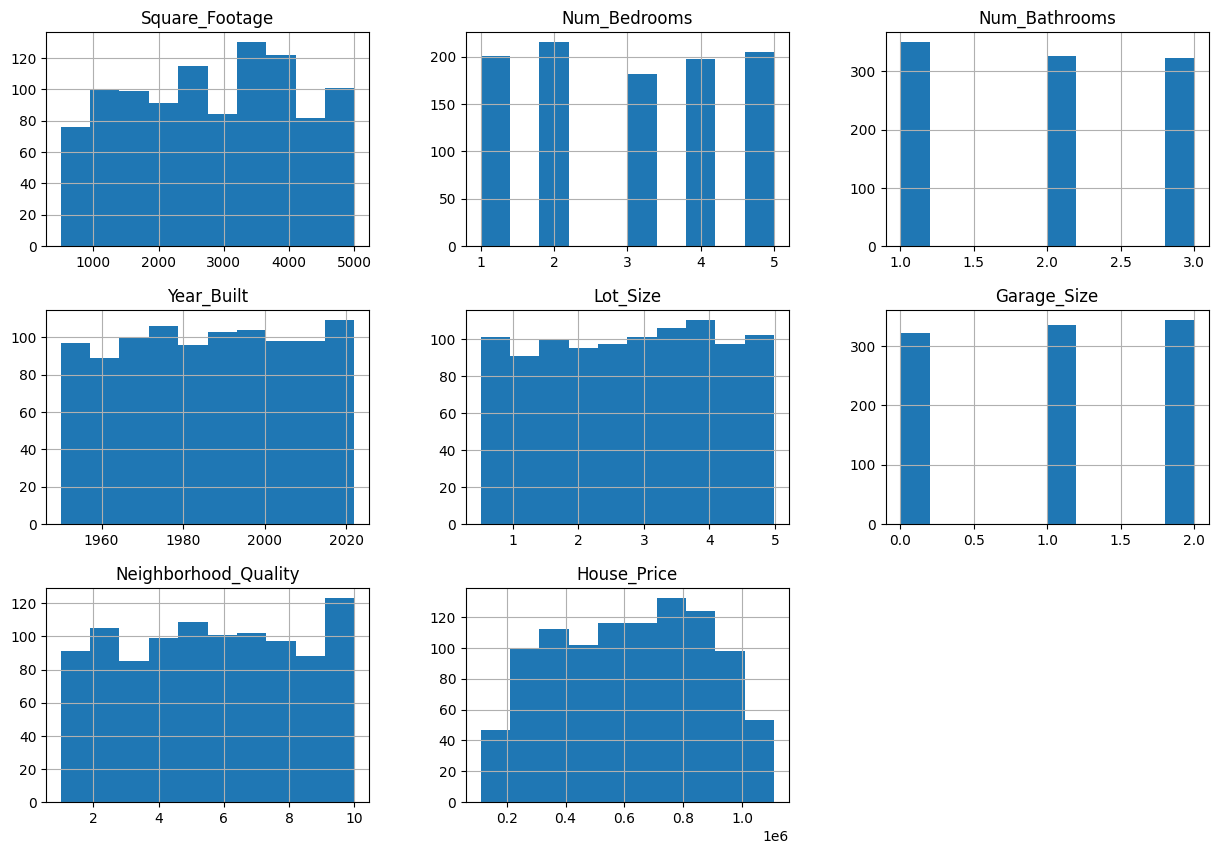

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

data.hist(figsize=(15,10))
plt.show()

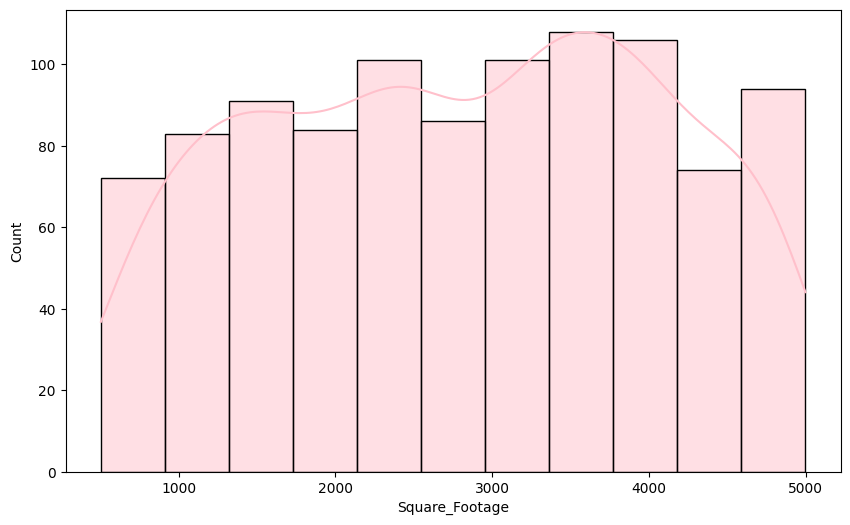

In [27]:
from matplotlib.typing import ColourType
#check distribution of square_footage
plt.figure(figsize=(10,6))
sns.histplot(data=data,x='Square_Footage',kde=True,color='pink')
plt.show()

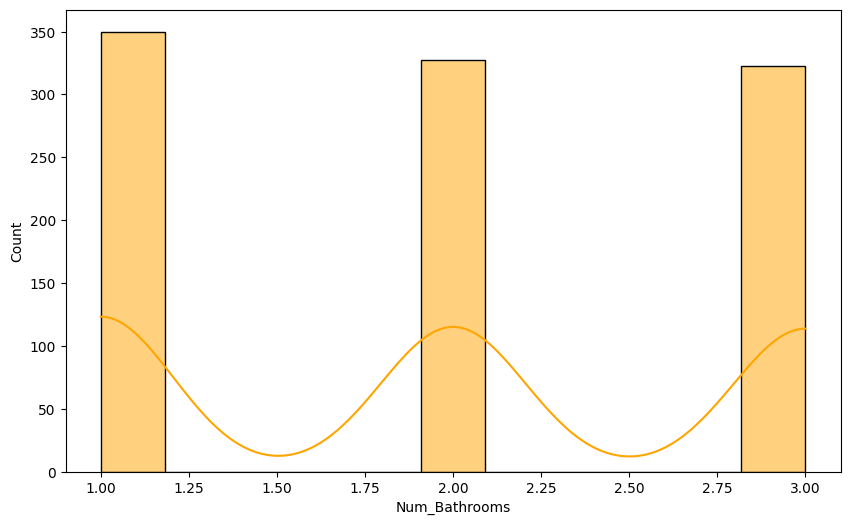

In [28]:
#check distribution of bedrooms
plt.figure(figsize=(10,6))
sns.histplot(data=data,x='Num_Bathrooms',kde=True,color='orange')
plt.show()

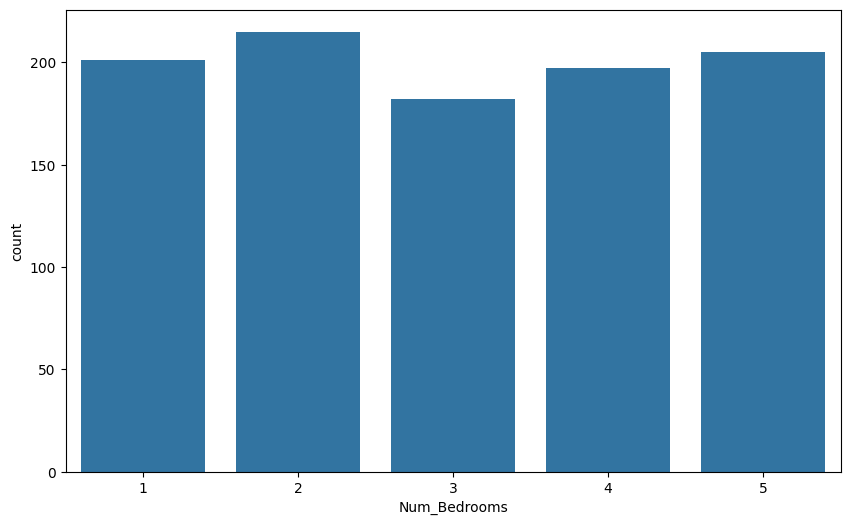

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(data=data,x='Num_Bedrooms')
plt.show()

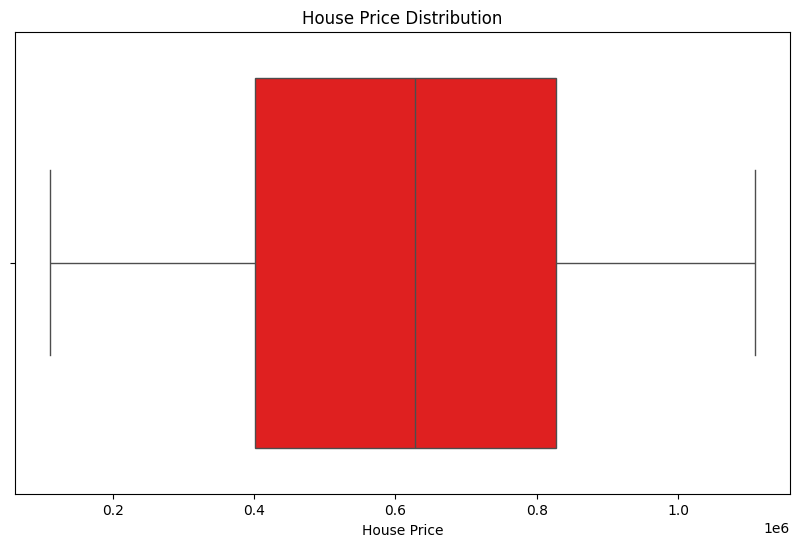

In [30]:
# check the distribution of house price
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='House_Price',color='red')
plt.title('House Price Distribution')
plt.xlabel('House Price')
plt.show()

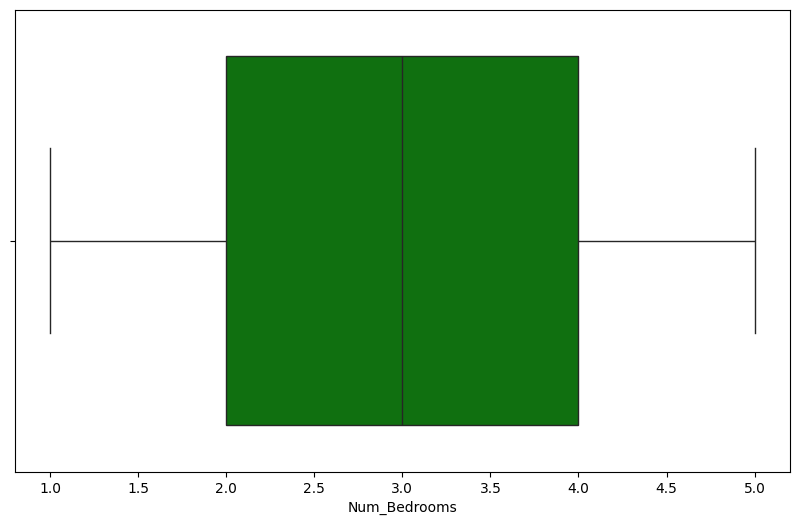

In [31]:
#check any outliners in bedrooms
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='Num_Bedrooms',color='green')
plt.show()

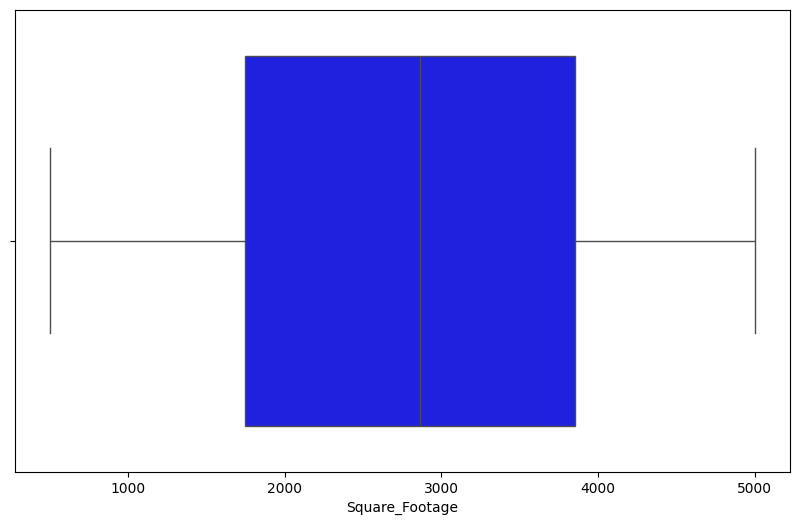

In [32]:
#check are the any outliners in square_feet
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='Square_Footage',color='blue')
plt.show()

**Bivariate analysis**

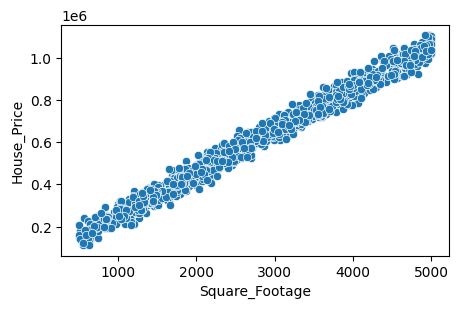

In [33]:
plt.figure(figsize=(5,3))

sns.scatterplot(data=data, x='Square_Footage', y='House_Price')

plt.show()

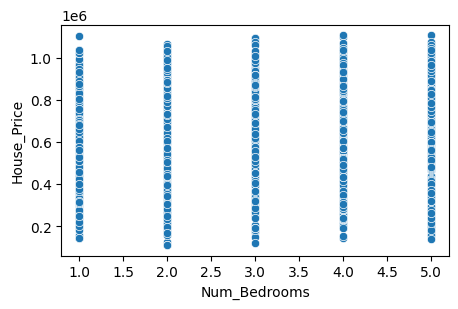

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

sns.scatterplot(data=data, x='Num_Bedrooms', y='House_Price')

plt.show()

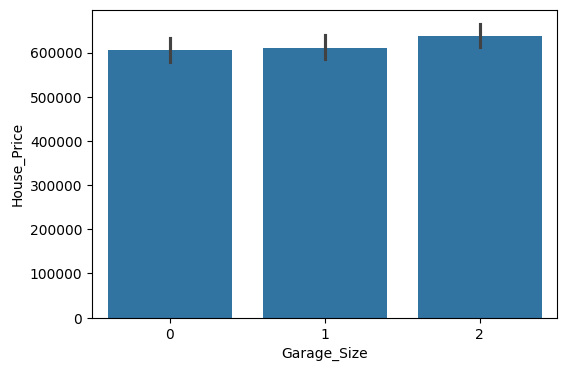

In [35]:
plt.figure(figsize=(6,4))
sns.barplot(data=data, x='Garage_Size',y='House_Price')
plt.show()

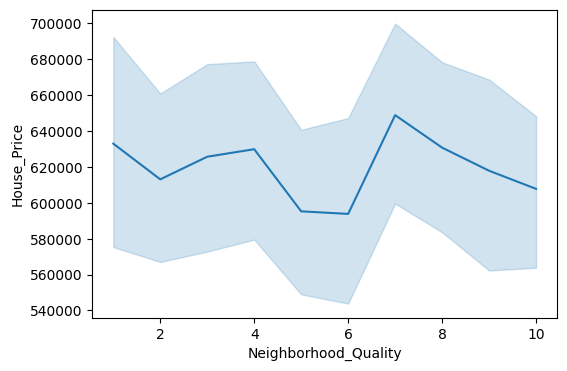

In [36]:
plt.figure(figsize=(6,4))
sns.lineplot(data=data, x='Neighborhood_Quality',y='House_Price')
plt.show()


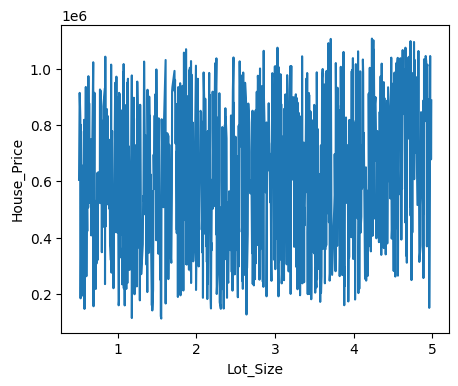

In [37]:
plt.figure(figsize=(5,4))
sns.lineplot(data=data,x='Lot_Size',y='House_Price')
plt.show()

**Generate Correlation Heatmap**

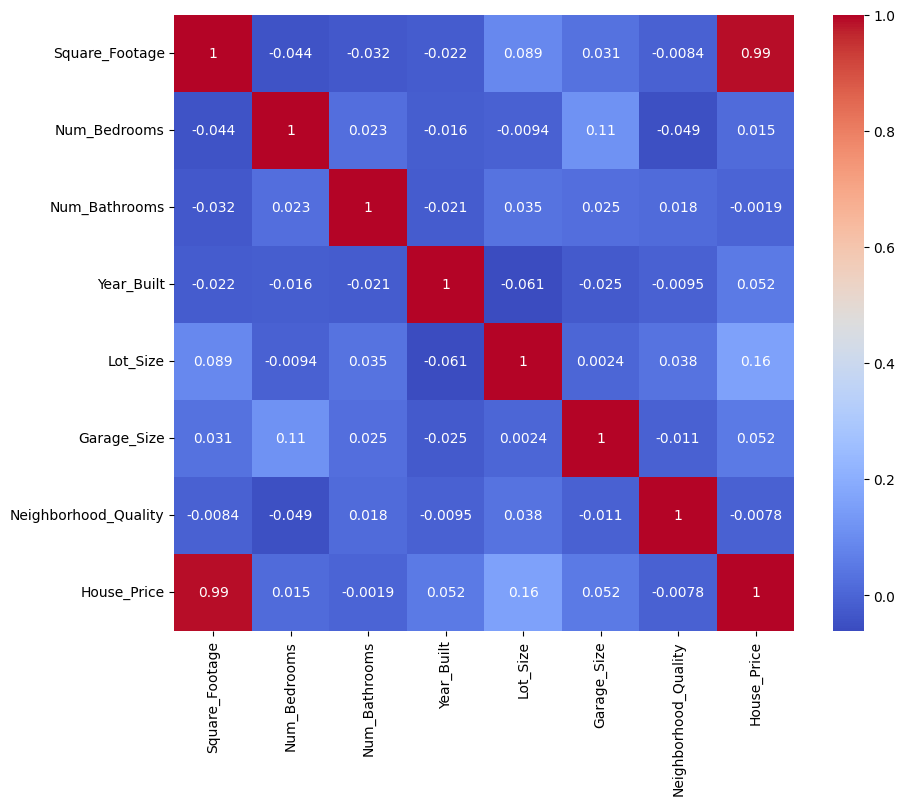

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [39]:
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

**Detect and Handle Outliners**

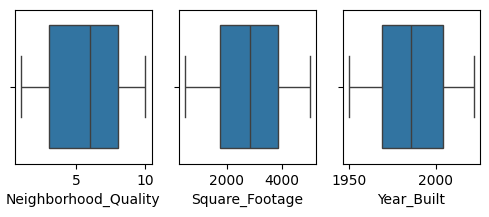

In [40]:
fig,ax=plt.subplots(1,3,figsize=(6,2))
sns.boxplot(data=data,x='Neighborhood_Quality',ax=ax[0])
sns.boxplot(data=data,x='Square_Footage',ax=ax[1])
sns.boxplot(data=data,x='Year_Built',ax=ax[2])
plt.show()

clearly shows there is no outliners

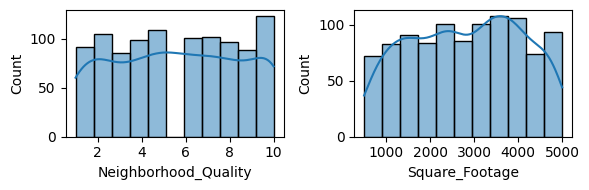

In [41]:
#check the distribution of neighborhoodquality and square footage
fig,ax=plt.subplots(1,2,figsize=(6,2))
sns.histplot(data=data,x='Neighborhood_Quality',ax=ax[0],kde=True)
sns.histplot(data=data,x='Square_Footage',ax=ax[1],kde=True)
plt.tight_layout()
plt.show()

In [42]:
#skewness of neighborhood_quality and Square_Footage
data.loc[:,'Neighborhood_Quality'].skew()


np.float64(-0.020444819217800444)

In [43]:
data.loc[:,'Square_Footage'].skew()

np.float64(-0.06600064579808387)

**Seperate features and Target Variables**

In [44]:
X = data.drop('House_Price', axis=1)   # features
y = data['House_Price']                # target

**Train-Test Split**

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**Apply feature scaling **

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [47]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train Regression Models**

In [48]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [49]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [50]:
y_pred_model=model.predict(X_test)

**KNN Regression**

In [51]:
from sklearn.neighbors import KNeighborsRegressor
knn_model=KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train,y_train)

KNeighborsRegressor()

In [52]:
y_pred_knn = knn_model.predict(X_test)

**Evaluate Models**

In [53]:
from sklearn.metrics import mean_absolute_error ,mean_squared_error, r2_score

**Mean Squared Error**

In [78]:
mean_squared_error(y_test,y_pred_model)

101434798.50563587

**Mean absolute error**

In [59]:
mean_absolute_error(y_test,y_pred_model)

8174.583600006616

**Root Mean squared Error**

In [62]:
from sklearn.metrics import mean_squared_error
np.sqrt(mean_squared_error(y_test,y_pred_model))

np.float64(10071.484424137083)

**Mean Absolute Percentage Error**

In [63]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_test,y_pred_model)

0.016639061459737356

**R2 Score**

In [64]:
from sklearn.metrics import r2_score
r2= r2_score(y_test,y_pred_model)
r2

0.9984263636823413

**Adjusted r2 score**

In [66]:
n=X_test.shape[0]
p=X_test.shape[1]

In [67]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9983689915249266

**Evaluate models for KNN Regression**

In [69]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,root_mean_squared_error

**Mean Squared error**

In [70]:
mean_squared_error(y_test,y_pred_knn)

6986408437.145264

**Mean Absolute Percentage Error**

In [74]:
mean_absolute_error(y_test,y_pred_knn)

69823.26478552072

**Root Mean squared Error**

In [73]:
np.sqrt(mean_squared_error(y_test,y_pred_knn))

np.float64(83584.73806350812)

**Mean Absolute Percentage Error**

In [72]:
mean_absolute_percentage_error(y_test,y_pred_knn)

0.1529885459008446

R2 Score

In [75]:
from sklearn.metrics import r2_score
r2= r2_score(y_test,y_pred_knn)
r2

0.8916144537313003

**Adjusted r2 score**

In [76]:
n = X_test.shape[0]
p = X_test.shape[1]

In [77]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8876628973569206